# Calibration X6Y3 — the FULL flow (co-simulation)

The complete X6Y3 calibration chain (spec
[two-qubit/04](../specs/two-qubit/04-x6y3-fixed-frequency.md) §2) end-to-end against the Verilated
`PulseTableSoc` — readout → 1Q GE → EF subspace → two-qubit (JAZZ + the **two-qubit-drive** CZ
chain) → an R validation — every stage the run → fit → `apply()` → `save_qcal` round trip through a
qcal tree ([`calibration_x6y3_full_cosim.yaml`](calibration_x6y3_full_cosim.yaml)). The on-hardware
twin — the same flow on the real 8-qubit ring — is
[`calibration_x6y3_full.ipynb`](calibration_x6y3_full.ipynb).

The build is **sim-2q1c** (3 cores): qubits 0/1 are the calibrated pair, core 2 the ring neighbour
`SpectatorPhase` needs — its READOUT is calibrated alongside the pair's in section 1 (the spectator
Ramsey reads through core 2's own discriminator). Each section plants its OWN ground-truth model (`drv.sim.set_model` is
reconfigurable), against ONE evolving working tree:

| section | model | what converges |
|---|---|---|
| readout + 1Q | two `TwoLevelModel`s, readout tones summed on the shared ADC | demod phase/`res_sign`, readout freq/amp, `qubit/{q}/freq` (planted ±40-code errors), X90 amp (planted odd-multiple Rabi rates), X90 virtual-Z |
| EF | two `ThreeLevelModel`s (planted f_EF ∓60 codes off the tree, EF Rabi rates) | the 3-level `ClassifierN`, `EF/freq`, `EF/x90/amp`, `EF/x/amp`, `EF/rabi`, `EF/x90/vz` |
| two-qubit | ONE drive-form `TwoQubitModel` (no `"coupler"` key — the X6Y3 form, X3) + a `TwoLevelModel` bystander for the spectator stage | `CZ/freq` (seed + dip + R-argmax), the target line's relative phase (planted 2.0 rad off), both lines' amp, the ZI/IZ local-phase virtual-Zs, the Q2 spectator virtual-Z |

**Knobs are co-sim-scaled** (spec 13 §2: on-core loops, 12–32 shots, `relax` = 2400 batches ≫
t1 = 600 — 0.75× the single-qubit twin's budget so the WHOLE chain fits one CI run) and the gate is
the **CODE PATH**: every stage runs, fits, and writes through the real kernels/link/DACs/model.
Where physics recovery through the collapse readout is relaxation-SNR-limited (JAZZ's ZZ magnitude,
the CZ chain's fine values — spec 01 §4.3/§4.6, 04 §5), the DAC-level correctness is pinned by the
committed co-sim gates (`test_twoqubit_cosim`) and the recovery math host-side (`test_twoqubit`,
`test_models`); the notebook demonstrates the FLOW, and prints planted vs recovered wherever the
model gives a clean handle.

In [1]:
import math
import shutil
import time
from pathlib import Path

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import riscq
from riscq import run as rq
from riscq.cal import (Amplitude, CZAmplitude, CZFrequency, CZSweep, ClassifierN, Config,
                       EFAmplitude, EFFrequency, EFPhase, Fidelity, Frequency, JAZZ, LocalPhases,
                       Phase, ReadoutCalibration, ReadoutFidelity, RelativePhase, Separation,
                       SpectatorPhase, calc_cz_frequency, pair_key)
from riscq.cal.base import GATE_ENV, acquire_shots, batch_timeout, ef_pulse, gate_pulse, gate_sigma
from riscq.cal.readout import _rawiq_prog
from riscq.cal.twoqubit import _cz_cond_R, _cz_dur_batches, _cz_freq_word, _cz_pulse
from riscq.map import SocMap, SocParams
from riscq.pulses import Pulse, units
from riscq.sim import server

MHz, us = 1e6, 1e-6
T0 = time.time()

def mark(label):
    print(f'[{time.time() - T0:7.1f}s] {label}')

## Bring up the co-sim and the config of record

The config of record is the full-flow qcal tree — GE + EF per qubit, readout 0/1/2, the
`two_qubit/(0, 1)` drive-form CZ entry (two drive lines + Q0/Q1/Q2 virtual-Z entries) — copied to a
**working file** that every cell reloads and every applied proposal is saved back into
(`Config.from_qcal` → calibrate → `save_qcal`, spec 13 §3 + the X0 EF/two-qubit adapter).

In [2]:
SW = Path(riscq.__file__).resolve().parents[1]              # .../software
SRC = SW.parent / 'examples' / 'calibration_x6y3_full_cosim.yaml'
WORK = SW / 'build' / 'calibration_x6y3_full_config.yaml'   # the working copy
WORK.parent.mkdir(exist_ok=True)
shutil.copy(SRC, WORK)

drv = server.start(SW / 'configs' / 'sim-2q1c.json', SW / 'build' / 'sim-2q1c')
m = SocMap(SocParams.from_json(drv.sim.get_params()))
QUBITS = [0, 1]                  # the calibrated pair (one per core)
PAIR = (0, 1)
SPECT = 2                        # the ring neighbour (core 2) — SpectatorPhase's bystander
ALL = [0, 1, SPECT]              # readout is calibrated on ALL cores (the spectator's fringe
                                 # reads through its OWN discriminator, so S1 must train it too)

cfg = Config.from_qcal(WORK)
cfg.check_hardware(m.params)     # the tree's hardware section must describe THIS build (spec 13 Q0)
print('cosim up; qubits =', QUBITS, ' spectator =', SPECT, ' herald =', cfg['readout/herald'])

def step(cal):
    '''run -> print -> apply if ok -> persist to the working tree (qcal's auto write-back).'''
    t = time.time()
    r = cal.run(drv)
    print(f'{r.label}: ok={r.ok}  [{time.time() - t:.0f}s]  proposal={r.proposal}')
    if r.ok:
        r.apply()
        r.cfg.save_qcal(WORK)
    else:
        print('  fit failed — config left unchanged (fail-loud, spec 13 §2)')
    return r

cosim up; qubits = [0, 1]  spectator = 2  herald = True


## Plant the readout + 1Q ground truth and mis-set the starting tree

Each core gets a projective `TwoLevelModel` at its OWN carrier (q0 = 50 MHz, q1 = 150 MHz — every
gate-side code in this notebook is a multiple-of-4096 away from its line's other references, the
exact 16-sample demod null) with a **planted** Rabi rate — odd multiples of π per full-scale
X90·X90, so the uncalibrated prep still lands on |1⟩ for the readout steps. The readout tones sum
on the shared ADC (`kind: multi`, spec 13 §8). The working tree then gets deliberate errors to
recover: each qubit's frequency off by ±40 codes (both update signs) on top of the tree's
uncalibrated X90 amp (0.5).

In [3]:
F_GE = {0: 50e6, 1: 150e6, 2: 100e6}       # codes 2048 / 6144 / 4096
F_EF = {0: 450e6, 1: 650e6}                 # codes 18432 / 26624
RO_CODE = {0: 2048, 1: 1024, 2: 3072}       # the readout multiplex slots

def x90_sigma(q, amp):
    '''The drive integral of one full X90 at `amp` — the σ the models integrate (base.gate_sigma).'''
    p = Pulse(GATE_ENV, freq_hz=F_GE[q], amp=amp)
    return gate_sigma(m, p, F_GE[q], units._amp_code(amp))

SIG_MAX = {q: x90_sigma(q, 0.97) for q in ALL}
RABI = {0: 3 * math.pi / SIG_MAX[0], 1: 5 * math.pi / SIG_MAX[1],   # odd multiples of π full-scale
        2: math.pi / SIG_MAX[2]}                                    # spectator: a plain π prep
TRUE_AMP = {q: 0.97 * (math.pi / 2) / (RABI[q] * SIG_MAX[q]) for q in QUBITS}

# readout budget: relax (2400) >> t1 (600) >> SEP. The cluster separation is T1-DECAY-bounded, not
# noise-bounded (a |1>-prep shot that relaxes in the ~20 batches before the readout latch lands in
# the |0> cluster and inflates the |1> cloud), so t1 keeps the 1Q twin's 600 while the relax head
# drops to 0.75x; the three summed tones (3 x 10000) stay in converter range.
def twolevel_models():
    return [dict(kind='twolevel', core=q, rabi_rad_per_amp=RABI[q], readout_code=RO_CODE[q],
                 readout_amp=10000.0, readout_phase=0.0, f_ge=F_GE[q], t1=600, t2=3000,
                 noise_scale=200.0, noise_seed=11 + q, collapse=True) for q in ALL]

drv.sim.set_model({'kind': 'multi', 'models': twolevel_models()})

D_CODE = {0: +40, 1: -40}
cfg = Config.from_qcal(WORK)
for q in QUBITS:
    off = units._freq_code(F_GE[q], m.params) + D_CODE[q]
    cfg[f'qubit/{q}/freq'] = float(units.code_to_freq(off, m.params))
cfg.save_qcal(WORK)
for q in QUBITS:
    print(f"q{q}: start freq err {abs(cfg[f'qubit/{q}/freq'] - F_GE[q]):.4g} Hz   "
          f"X90 amp {cfg[f'qubit/{q}/x90/amp']} (true ~{TRUE_AMP[q]:.4f})")

q0: start freq err 9.766e+05 Hz   X90 amp 0.5 (true ~0.1617)
q1: start freq err 9.766e+05 Hz   X90 amp 0.5 (true ~0.0970)


# Section 1 — readout

`ReadoutCalibration` fixes each qubit's `demod/phase` + `res_sign` (the on-chip discriminator) off
the |0⟩/|1⟩ RAW clusters; `Separation` re-pins `readout/{q}/freq` by the cluster-SNR argmax (a
narrow ±1.5 MHz here — the demod window's discrimination width at 40 batches is ~2.5 MHz, and a
noisy argmax landing a full span off would detune every later readout); `Fidelity` sweeps the
readout amp under the FIXED discriminator; `ReadoutFidelity` records the confusion matrix. The
spec-13 chain, both qubits at once, heralded.

[    2.6s] S1 readout


ReadoutCalibration [0, 1, 2]: ok=True  [40s]  proposal={'readout/0/demod/phase': 1.5331437136281953, 'readout/0/res_sign': 1, 'readout/1/demod/phase': 0.729408155604452, 'readout/1/res_sign': 1, 'readout/2/demod/phase': 2.3626716411065054, 'readout/2/res_sign': 1}


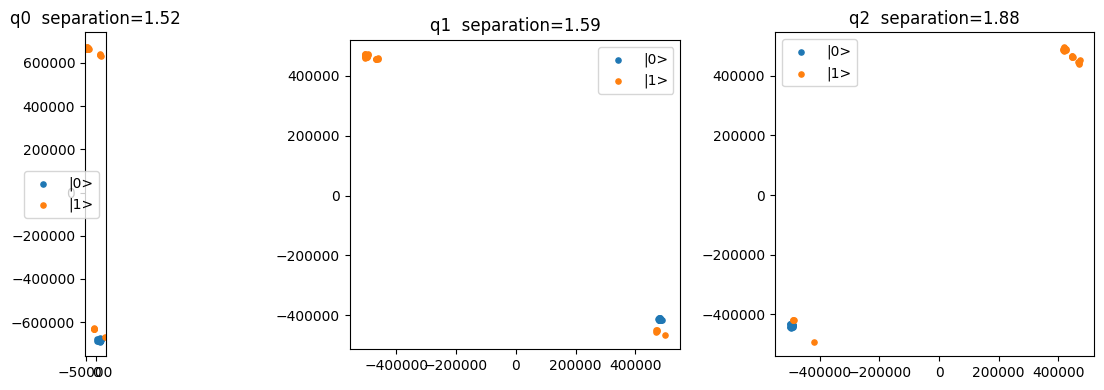

In [4]:
mark('S1 readout')
cfg = Config.from_qcal(WORK)
rc = step(ReadoutCalibration(cfg, ALL, shots=32, gate='X90'))

fig, axes = plt.subplots(1, len(ALL), figsize=(12, 4))
for q, ax in zip(ALL, axes):
    d = rc.data[q]
    ax.scatter(d['iq0'][:, 0], d['iq0'][:, 1], s=14, label='|0>')
    ax.scatter(d['iq1'][:, 0], d['iq1'][:, 1], s=14, label='|1>')
    ax.set_title(f"q{q}  separation={d['separation']:.2f}")
    ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()
assert rc.ok, 'the discriminator must train — everything downstream reads through it'

Separation [0, 1, 2]: ok=False  [131s]  proposal={'readout/0/freq': 11010742.1875, 'readout/1/freq': 4760742.1875, 'readout/2/freq': 17260742.1875}
  fit failed — config left unchanged (fail-loud, spec 13 §2)


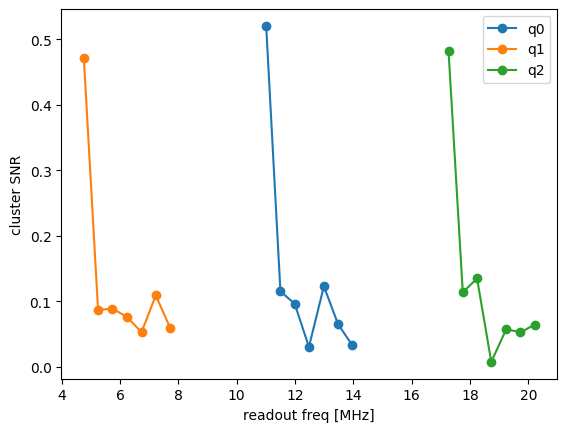

readout/0/freq -> 12.5000 MHz (+0.00 MHz off the planted tone)
readout/1/freq -> 6.2500 MHz (+0.00 MHz off the planted tone)
readout/2/freq -> 18.7500 MHz (+0.00 MHz off the planted tone)


In [5]:
cfg = Config.from_qcal(WORK)
sep = step(Separation(cfg, ALL, span=1.5 * MHz, points=7, shots=16, gate='X90'))

for q in ALL:
    plt.plot(sep.data[q]['x'] / MHz, sep.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('readout freq [MHz]'); plt.ylabel('cluster SNR'); plt.legend(); plt.show()
for q in ALL:
    shift = cfg[f'readout/{q}/freq'] - float(units.demod_code_to_freq(RO_CODE[q], m.params))
    print(f"readout/{q}/freq -> {cfg[f'readout/{q}/freq'] / MHz:.4f} MHz "
          f'({shift / MHz:+.2f} MHz off the planted tone)')

Fidelity [0, 1, 2]: ok=True  [97s]  proposal={'readout/0/amp': 0.49502412545235225, 'readout/1/amp': 0.49502412545235225, 'readout/2/amp': 0.49502412545235225}


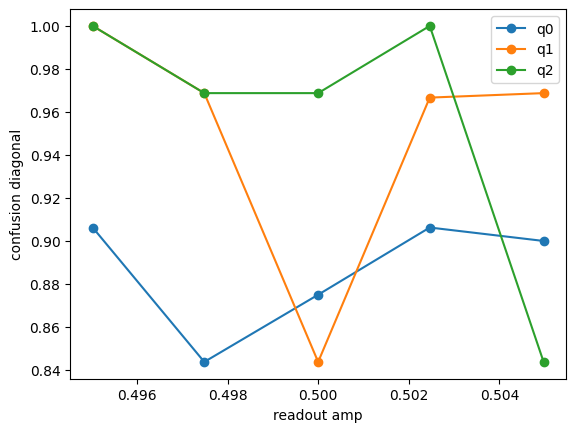

In [6]:
cfg = Config.from_qcal(WORK)
fid = step(Fidelity(cfg, ALL, amp_span=0.005, points=5, shots=16, gate='X90'))

for q in ALL:
    plt.plot(fid.data[q]['x'], fid.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('readout amp'); plt.ylabel('confusion diagonal'); plt.legend(); plt.show()

In [7]:
cfg = Config.from_qcal(WORK)
rof = step(ReadoutFidelity(cfg, ALL, shots=32, gate='X90'))

for q in ALL:
    print(f'q{q} confusion (row = prepared, col = classified):')
    print(np.round(rof.data[q]['confusion'], 3), f"  fidelity={rof.data[q]['fidelity']:.3f}")

ReadoutFidelity [0, 1, 2]: ok=True  [43s]  proposal={'readout/0/fidelity': 0.9032258064516129, 'readout/1/fidelity': 0.890625, 'readout/2/fidelity': 0.84375}
q0 confusion (row = prepared, col = classified):
[[1.    0.   ]
 [0.194 0.806]]   fidelity=0.903
q1 confusion (row = prepared, col = classified):
[[1.    0.   ]
 [0.219 0.781]]   fidelity=0.891
q2 confusion (row = prepared, col = classified):
[[1.    0.   ]
 [0.312 0.688]]   fidelity=0.844


# Section 2 — single qubit (GE)

`Frequency`: Ramsey fringes at ±3/±6 MHz applied detunings, qcal's `a·|x − b| + c` V-fit — both
planted signs (±40 codes) must correct toward the planted carrier. `Amplitude`: the coarse
`n_gates=1` Rabi cosine, then the fine 4-X90 relative pass. `Phase`: the `Y180_X90`/`X180_Y90`
line crossing on the X90's virtual-Z pair (the model plants no AC-Stark term, so the crossing sits
near 0).

These are COUNTS-mode differential fits — relaxation carryover only scales their contrast, unlike
the RAW cluster captures — so the section runs on a shorter in-memory `relax` = 1600 grid (reset is
not a calibrated artefact; the tree keeps the RAW-budget 2400).

[  313.1s] S2 1Q GE


Frequency [0, 1]: ok=True  [347s]  proposal={'qubit/0/freq': 50008682.518267855, 'qubit/1/freq': 149981134.0993924}


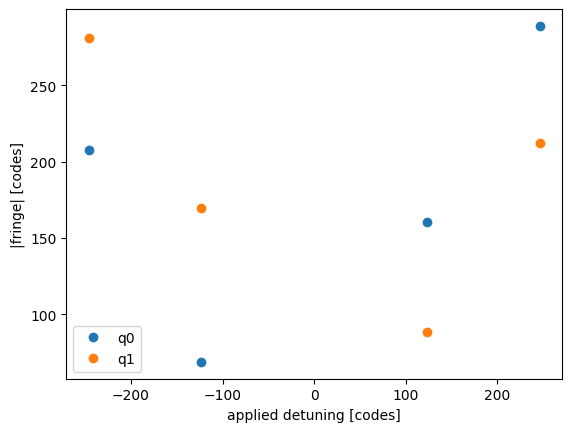

q0: freq err 9.766e+05 -> 8683 Hz
q1: freq err 9.766e+05 -> 1.887e+04 Hz


In [8]:
RELAX_1Q = 1.6e-05               # counts-mode grid (in-memory; the tree keeps the RAW budget)

def cfg1q():
    c = Config.from_qcal(WORK)
    c['reset/relax'] = RELAX_1Q
    return c

mark('S2 1Q GE')
cfg = cfg1q()
fr = step(Frequency(cfg, QUBITS, detune=3 * MHz, n_detune=4, t0=40e-9, dt=40e-9,
                    points=11, shots=20))

for q in QUBITS:
    d = fr.data[q]
    plt.plot(d['applied'], d['obs'], 'o', label=f'q{q}')
plt.xlabel('applied detuning [codes]'); plt.ylabel('|fringe| [codes]'); plt.legend(); plt.show()
for q in QUBITS:
    d0 = abs(units.code_to_freq(units._freq_code(F_GE[q], m.params) + D_CODE[q], m.params) - F_GE[q])
    print(f"q{q}: freq err {d0:.4g} -> {abs(cfg[f'qubit/{q}/freq'] - F_GE[q]):.4g} Hz")

Amplitude [0, 1] X90 n_gates=1: ok=True  [196s]  proposal={'qubit/0/x90/amp': 0.152568518252068, 'qubit/0/rabi': 7.857222425526317e-05, 'qubit/1/x90/amp': 0.09460590911351517, 'qubit/1/rabi': 0.0001267219123138869}


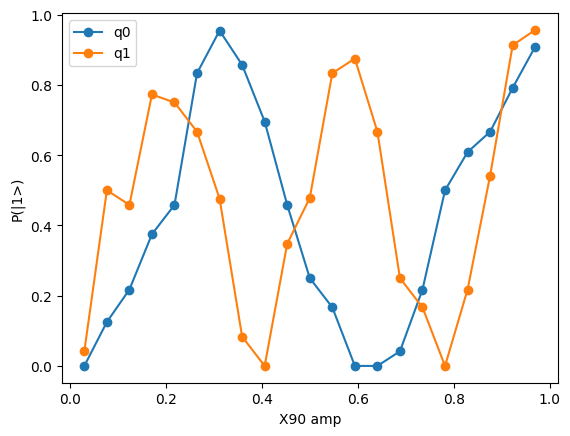

Amplitude [0, 1] X90 n_gates=4: ok=True  [86s]  proposal={'qubit/0/x90/amp': 0.16017075074768403, 'qubit/1/x90/amp': 0.09429046564588119}
q0: X90 amp -> 0.1602 (true ~0.1617)
q1: X90 amp -> 0.0943 (true ~0.0970)


In [9]:
cfg = cfg1q()
ac = step(Amplitude(cfg, QUBITS, gate='X90', n_gates=1, amp_span=(0.03, 0.97), points=21, shots=24))

for q in QUBITS:
    plt.plot(ac.data[q]['x'] / units.AMP_SCALE, ac.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('X90 amp'); plt.ylabel('P(|1>)'); plt.legend(); plt.show()

cfg = cfg1q()
af = step(Amplitude(cfg, QUBITS, gate='X90', n_gates=4, amp_span=(0.7, 1.3), relative_amp=True,
                    points=9, shots=24))
for q in QUBITS:
    print(f"q{q}: X90 amp -> {cfg[f'qubit/{q}/x90/amp']:.4f} (true ~{TRUE_AMP[q]:.4f})")

In [10]:
cfg = cfg1q()
ph = step(Phase(cfg, QUBITS, span=0.3, points=7, shots=16))    # the absolute pass

for q in QUBITS:
    vz = cfg[f'qubit/{q}/x90/vz']
    print(f'q{q}: X90 virtual-Z pair -> [{vz[0]:+.4f}, {vz[1]:+.4f}] rad  (planted 0)')

Phase [0, 1]: ok=True  [93s]  proposal={'qubit/0/x90/vz': [-0.27109484518565335, -0.27109484518565335], 'qubit/1/x90/vz': [-0.04371782685083068, -0.04371782685083068]}
q0: X90 virtual-Z pair -> [-0.2711, -0.2711] rad  (planted 0)
q1: X90 virtual-Z pair -> [-0.0437, -0.0437] rad  (planted 0)


# Section 3 — EF subspace

The |1⟩→|2⟩ manifold (spec 04 §2 / X4). The models switch to per-qubit `ThreeLevelModel`s: planted
EF Rabi rates, the true f_EF ∓60 codes off the (mis-set) tree, `t1` so the grid's relax head resets
each shot. The hardware `res` bit cannot tell |1⟩ from |2⟩, so first the 3-level **`ClassifierN`**
trains from per-level RAW reference clouds — in co-sim each level is PLANTED on the model
(`init_level`) and read out; the hardware twin preps |2⟩ with the tree's stored EF X instead. All
EF cals then read P(|2⟩) through it, both qubits in parallel.

[ 1036.2s] S3 EF — 3-level classifier


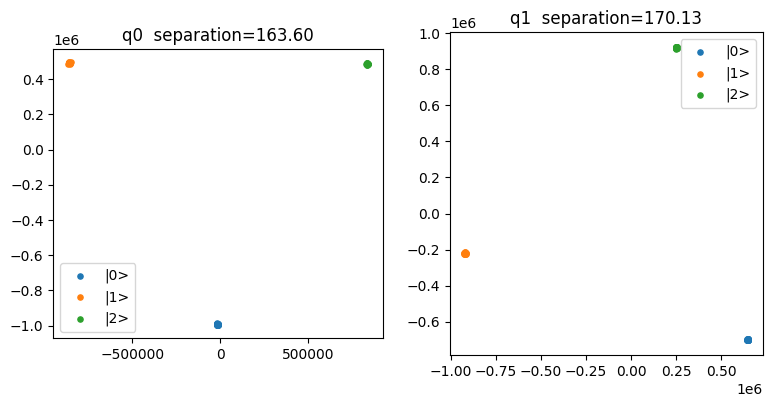

In [11]:
mark('S3 EF — 3-level classifier')
cfg = Config.from_qcal(WORK)

def train_classifiers(shots=24):
    progs, timeout = {}, 0
    for q in QUBITS:
        prog, period = _rawiq_prog(m, cfg, q, 'X90', shots)
        progs[q] = prog
        timeout = max(timeout, batch_timeout(shots * period))
    clouds = {q: [] for q in QUBITS}
    for level in range(3):                     # plant each level on BOTH models, capture RAW clouds
        drv.sim.set_model({'kind': 'multi', 'models': [
            dict(kind='threelevel', core=q, readout_code=RO_CODE[q], readout_amp=15000.0,
                 init_level=level, collapse=True, noise_scale=200.0, noise_seed=7 + 3 * q + level)
            for q in QUBITS]})
        rq.setup(drv, m, progs)
        iq = acquire_shots(drv, m, progs, 0, shots, timeout)
        for q in QUBITS:
            clouds[q].append(iq[q])
    return {q: ClassifierN(clouds[q]) for q in QUBITS}

CLF = train_classifiers()
fig, axes = plt.subplots(1, len(QUBITS), figsize=(8, 4))
for q, ax in zip(QUBITS, axes):
    for lvl, c in enumerate(CLF[q].clusters):
        ax.scatter(c[:, 0], c[:, 1], s=14, label=f'|{lvl}>')
    ax.set_title(f'q{q}  separation={CLF[q].separation:.2f}')
    ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()
assert all(CLF[q].separation > 1.0 for q in QUBITS), '3-level clusters must separate'

In [12]:
def rabi_ge_pi(q):
    '''The GE Rabi rate that makes the CALIBRATED X90·X90 prep a full π (reads the working tree).'''
    a = float(cfg[f'qubit/{q}/x90/amp'])
    gp = gate_pulse(cfg, q, m)
    return (math.pi / 2) / gate_sigma(m, gp, float(cfg[f'qubit/{q}/freq']), units._amp_code(a))

RABI_EF = {}                                   # ONE EF Rabi period over the amp sweep (the X4 gate)
for q in QUBITS:
    RABI_EF[q] = 2 * math.pi / gate_sigma(m, ef_pulse(cfg, q, m), F_EF[q], units._amp_code(0.97))

def ef_models(seed):
    return [dict(kind='threelevel', core=q, f_ge=F_GE[q], f_ef=F_EF[q],
                 rabi_ge_rad_per_amp=rabi_ge_pi(q), rabi_ef_rad_per_amp=RABI_EF[q],
                 readout_code=RO_CODE[q], readout_amp=15000.0, init_level=0, collapse=True,
                 t1=600, noise_scale=200.0, noise_seed=seed + q) for q in QUBITS]

D_EF = {0: +60, 1: -60}                        # the planted EF carrier errors (both signs)
cfg = Config.from_qcal(WORK)
for q in QUBITS:
    off = units._freq_code(F_EF[q], m.params) + D_EF[q]
    cfg[f'qubit/{q}/EF/freq'] = float(units.code_to_freq(off, m.params))
cfg.save_qcal(WORK)
print('EF carriers mis-set by', D_EF, 'codes; planted EF Rabi rates:', RABI_EF)

EF carriers mis-set by {0: 60, 1: -60} codes; planted EF Rabi rates: {0: 4.943390667568951e-05, 1: 4.943390667568951e-05}


## EF Frequency

The EF Ramsey V-fit: GE π prep → retune to `EF/freq` → two EF X90s around a swept wait with a
virtual-Z detuning → P(|2⟩) fringes. The fringe MINIMISES where the applied detuning cancels the
planted error, and the corrected `qubit/{q}/EF/freq` moves toward the true f_EF — when the fits
land: the joint two-qubit V (a damped cosine per fringe through the 3-level clusters, all-or-
nothing across the pair) is MARGINAL at these co-sim shot counts and often refuses, leaving the
tree unchanged (fail-loud). The recovery physics itself is pinned by the committed single-qubit
co-sim gate (`test_ef_frequency_recovers_the_ef_detuning`, both plant signs, 36 shots).

[ 1084.0s] S3 EFFrequency


/config/build/agentic-rv-dev/software/riscq/cal/fits.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, x, y, p0=p0, maxfev=20000)


EFFrequency [0, 1]: ok=False  [468s]  proposal={}
  fit failed — config left unchanged (fail-loud, spec 13 §2)


/config/build/agentic-rv-dev/software/riscq/cal/fits.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model, x, y, p0=[a0 or sgn, b0, c0], maxfev=20000)


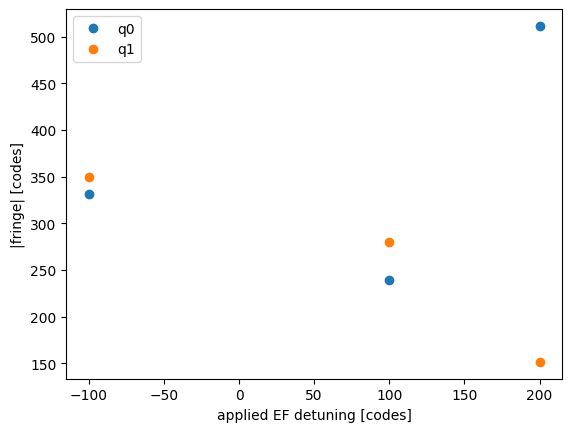

q0: EF freq err 1.465e+06 -> 1.465e+06 Hz
q1: EF freq err 1.465e+06 -> 1.465e+06 Hz


In [13]:
mark('S3 EFFrequency')
cfg = Config.from_qcal(WORK)
drv.sim.set_model({'kind': 'multi', 'models': ef_models(seed=23)})
# ladder ±100/±200 codes on the committed EF test's 40 ns wait grid: with the ∓60-code plants
# the fringes sit at {40, 140, 160, 260} codes — the three fast ones sample at ≥3.9 points per
# period and span ≥1.3 cycles (clean damped-cosine fits), the 40-code one is sub-cycle and drops
# by design (the V-fit needs 3).
efr = step(EFFrequency(cfg, QUBITS, CLF, detune=units.code_to_freq(100, m.params), n_detune=4,
                       t0=8e-08, dt=4e-08, points=9, shots=24))

for q in QUBITS:
    d = efr.data[q]
    plt.plot(d['applied'], d['obs'], 'o', label=f'q{q}')
plt.xlabel('applied EF detuning [codes]'); plt.ylabel('|fringe| [codes]'); plt.legend(); plt.show()
for q in QUBITS:
    d0 = abs(units.code_to_freq(units._freq_code(F_EF[q], m.params) + D_EF[q], m.params) - F_EF[q])
    print(f"q{q}: EF freq err {d0:.4g} -> {abs(cfg[f'qubit/{q}/EF/freq'] - F_EF[q]):.4g} Hz")

## EF Amplitude — X90, then X

The EF Rabi cosine over the amp sweep → `EF/x90/amp` + the recovered `EF/rabi` (planted: one full
period over the sweep, so the X90 lands near 0.97/4). The `gate='X'` pass calibrates the EF **π** —
`EF/x/amp`, the pulse an EF-sandwich CZ shelves with (the (5, 6)/(6, 7) prerequisite on the real
ring).

[ 1552.5s] S3 EFAmplitude X90 + X


EFAmplitude [0, 1] X90 n_gates=1: ok=True  [121s]  proposal={'qubit/0/EF/x90/amp': 0.06990255249459859, 'qubit/0/EF/rabi': 0.00017157710877171208, 'qubit/1/EF/x90/amp': 0.29316057555223074, 'qubit/1/EF/rabi': 4.0719603945944234e-05}


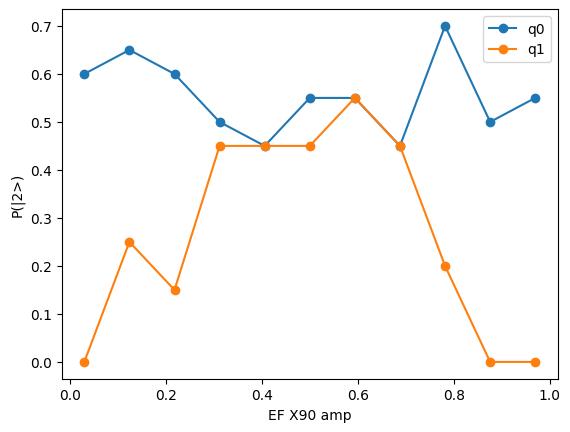

q0: EF rabi recovered/planted = 3.471
q1: EF rabi recovered/planted = 0.824


EFAmplitude [0, 1] X n_gates=1: ok=True  [121s]  proposal={'qubit/0/EF/x/amp': 0.11539460077075761, 'qubit/0/EF/rabi': 0.00010383087245302682, 'qubit/1/EF/x/amp': 0.23742745174680555, 'qubit/1/EF/rabi': 5.025986362018374e-05}
q0: EF x90 amp -> 0.0699   EF x amp -> 0.1154   (both ~0.2425 planted)
q1: EF x90 amp -> 0.2932   EF x amp -> 0.2374   (both ~0.2425 planted)


In [14]:
mark('S3 EFAmplitude X90 + X')
cfg = Config.from_qcal(WORK)
drv.sim.set_model({'kind': 'multi', 'models': ef_models(seed=27)})
efa_cal = EFAmplitude(cfg, QUBITS, CLF, gate='X90', n_gates=1, points=11, shots=20)
efa = step(efa_cal)

for q in QUBITS:
    plt.plot(efa.data[q]['x'] / units.AMP_SCALE, efa.data[q]['y'], 'o-', label=f'q{q}')
plt.xlabel('EF X90 amp'); plt.ylabel('P(|2>)'); plt.legend(); plt.show()
for q in QUBITS:
    print(f"q{q}: EF rabi recovered/planted = {efa_cal.recovered_rabi.get(q, float('nan')) / RABI_EF[q]:.3f}")

cfg = Config.from_qcal(WORK)
drv.sim.set_model({'kind': 'multi', 'models': ef_models(seed=29)})
efx = step(EFAmplitude(cfg, QUBITS, CLF, gate='X', n_gates=1, points=11, shots=20))
for q in QUBITS:
    print(f"q{q}: EF x90 amp -> {cfg[f'qubit/{q}/EF/x90/amp']:.4f}   "
          f"EF x amp -> {cfg[f'qubit/{q}/EF/x/amp']:.4f}   (both ~{0.97 / 4:.4f} planted)")

## EF Phase

The EF X90's virtual-Z pair (X4): GE π prep, retune to f_EF, the two Rz(±π/2)-decorated
three-EF-X90 sequences, P(|2⟩) line crossing → `qubit/{q}/EF/x90/vz` = [φ*, φ*]. The model plants
no EF Stark shift and the retune frame slip conjugates out of z-basis populations, so the crossing
sits near 0 — the gate is the code path + the key (the crossing math is host-verified, and the
committed `test_ef_phase_writes_the_vz_pair` pins the single-qubit recovery); the joint crossing
guard is chi2-strict and refuses on a marginal line pair rather than writing noise.

[ 1795.1s] S3 EFPhase


EFPhase [0, 1]: ok=False  [188s]  proposal={'qubit/0/EF/x90/vz': [-0.07264619242628895, -0.07264619242628895]}
  fit failed — config left unchanged (fail-loud, spec 13 §2)


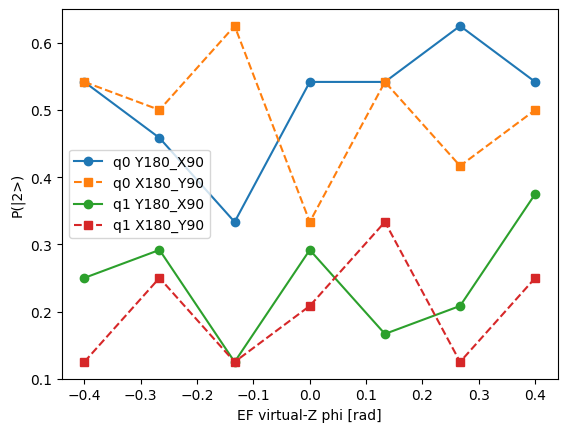

q0: EF X90 virtual-Z pair -> [+0.0000, +0.0000] rad
q1: EF X90 virtual-Z pair -> [+0.0000, +0.0000] rad


In [15]:
mark('S3 EFPhase')
cfg = Config.from_qcal(WORK)
drv.sim.set_model({'kind': 'multi', 'models': ef_models(seed=31)})
efp_r = step(EFPhase(cfg, QUBITS, CLF, points=7, span=0.4, shots=24))

for q in QUBITS:
    d = efp_r.data[q]
    plt.plot(d['x'], d['p0'], 'o-', label=f'q{q} Y180_X90')
    plt.plot(d['x'], d['p1'], 's--', label=f'q{q} X180_Y90')
plt.xlabel('EF virtual-Z phi [rad]'); plt.ylabel('P(|2>)'); plt.legend(); plt.show()
for q in QUBITS:
    vz = cfg.get(f'qubit/{q}/EF/x90/vz', [0.0, 0.0])
    print(f'q{q}: EF X90 virtual-Z pair -> [{vz[0]:+.4f}, {vz[1]:+.4f}] rad')

# Section 4 — two-qubit (the drive-form CZ chain)

ONE drive-form `TwoQubitModel` now holds the joint pair state (`coupler=None` — no `"coupler"` key,
the X6Y3 form): the CZ is two simultaneous in-band tones on the pair's own gate channels, the
model's activation is the **coherent two-line sum** |E| = 2A·cos(Δφ/2) rotating {|11⟩, |02⟩} (X3),
and its resonance sits at (f₁₁ + f₀₂)/4 computed from its own spectrum. Plants: `rabi_cz` sized so
the config's amp/duration give a full 2π round trip (the conditional π = a real CZ) at the OPTIMAL
relative phase Δφ = 0 — while the tree starts 2.0 rad off; a residual ZZ of +400 kHz; GE Rabi rates
matched to the freshly calibrated X90s.

The two-qubit stages run on the shorter `relax` = 800 grid the committed JAZZ/CZ co-sim gates use
(model t1 = 250 — the multi-pulse sequences must fit the model's coherence): `reset/relax` is not a
calibrated artefact (`save_qcal` round-trips the tree's own reset section untouched), so each cell
overrides it in-memory after the reload.

Physics through the COLLAPSE readout is the SNR-limited part (spec 01 §4.3/§4.4): expect visibly
noisy R/fringe values — each stage's run + fit + write is the gate, and the printed
planted-vs-recovered lines show what the model hands back at these shot counts.

In [16]:
mark('S4 two-qubit')
RELAX_2Q = 8e-06                     # 800 batches — the JAZZ/CZ co-sim gates' grid

def cfg2q():
    c = Config.from_qcal(WORK)
    c['reset/relax'] = RELAX_2Q      # in-memory only: reset is not a calibrated artefact
    return c

cfg = cfg2q()
CZ_AMP = 0.35
F_CZ_TRUE = (F_GE[0] + 2 * F_GE[1] + F_EF[1]) / 4          # the model's own resonance (code 10240)
czd = _cz_dur_batches(cfg, PAIR, m)
SIG_CZ = gate_sigma(m, _cz_pulse(cfg, PAIR, m, czd, 0), F_CZ_TRUE, units._amp_code(CZ_AMP))
RABI_CZ = math.pi / SIG_CZ           # two aligned lines: |E| = 2A -> a 2π round trip over czd
ZZ_TRUE = 2 * math.pi * 0.4e6 / m.params.dsp_freq_hz       # +400 kHz always-on ZZ

def twoqubit_model(seed):
    return dict(kind='twoqubit', control=0, target=1,      # NO 'coupler' key = the drive form (X3)
                f_ge=[F_GE[0], F_GE[1]], f_ef=[F_EF[0], F_EF[1]],
                rabi_ge=[rabi_ge_pi(0), rabi_ge_pi(1)], rabi_ef=[0.0, 0.0],
                rabi_cz_rad_per_amp=RABI_CZ, zz_rad_per_batch=ZZ_TRUE,
                readout_code=[RO_CODE[0], RO_CODE[1]], readout_amp=[10000.0, 10000.0],
                level_phases=[0.0, math.pi, math.pi / 2],  # 2-level pair readout; |2> reads as noise
                collapse=True, t1=250, noise_scale=250.0, noise_seed=seed)

drv.sim.set_model(twoqubit_model(seed=33))
print(f'czd={czd} batches  sig_cz={SIG_CZ:.1f}  rabi_cz={RABI_CZ:.3e} rad/amp/batch  '
      f'zz={ZZ_TRUE:.4f} rad/batch')

[ 1982.7s] S4 two-qubit
czd=30 batches  sig_cz=343999.6  rabi_cz=9.133e-06 rad/amp/batch  zz=0.0251 rad/batch


## The drive-form seed

`calc_cz_frequency(form='drive')` = (f₁₁ + f₀₂)/4 from the freshly calibrated 1Q spectrum — pure
config arithmetic (spec 04 §4.4), against the model's own resonance (the same arithmetic on the
PLANTED spectrum). The tree starts 8 MHz off; the seed lands within the EF-calibration residuals.
On the real chip's already-calibrated tree the seed is only a cross-check (see the hardware twin).

In [17]:
cfg = Config.from_qcal(WORK)
print(f"CZ/freq before: {cfg['two_qubit/(0, 1)/CZ/freq'] / MHz:.3f} MHz")
calc_cz_frequency(cfg, [PAIR], state='02', form='drive')
cfg.save_qcal(WORK)
print(f"drive-form seed: {cfg['two_qubit/(0, 1)/CZ/freq'] / MHz:.3f} MHz   "
      f'model resonance: {F_CZ_TRUE / MHz:.3f} MHz')

CZ/freq before: 242.000 MHz
drive-form seed: 249.627 MHz   model resonance: 250.000 MHz


## JAZZ — the residual ZZ

The BIRD-echo Ramsey (X90s + idles only): the target's fringe frequency differs between control
|0⟩/|1⟩ by exactly the ZZ. Writes `two_qubit/(0, 1)/ZZ11` into the working Config — note the qcal
artefact of record does NOT carry ZZ11 back (`save_qcal` writes only `CZ/freq` + `CZ/pulse`, a
known adapter gap), and the ZZ **magnitude** at co-sim shot counts is the SNR-limited quantity
(spec 01 §4.3) — the planted-vs-recovered print is a handle, not a gate.

JAZZ (0, 1): ok=True  [105s]  proposal={'two_qubit/(0, 1)/ZZ11': -164812.09998382768}


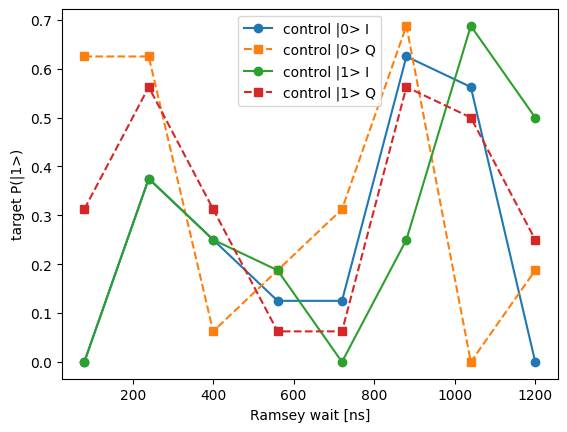

ZZ11 = f1 − f0 = -165 kHz   (planted +400 kHz; magnitude is SNR-limited here)


In [18]:
cfg = cfg2q()
jz = step(JAZZ(cfg, PAIR, detune=1.5e6, points=8, t0=40e-9, dt=80e-9, shots=16))

d = jz.data[PAIR]
for c, (ic, qc) in {0: ('I0', 'Q0'), 1: ('I1', 'Q1')}.items():
    plt.plot(d['t'] / 1e-9, d[ic], 'o-', label=f'control |{c}> I')
    plt.plot(d['t'] / 1e-9, d[qc], 's--', label=f'control |{c}> Q')
plt.xlabel('Ramsey wait [ns]'); plt.ylabel('target P(|1>)'); plt.legend(); plt.show()
zz = jz.proposal.get('two_qubit/(0, 1)/ZZ11', float('nan'))
print(f'ZZ11 = f1 − f0 = {zz / 1e3:+.0f} kHz   (planted +400 kHz; magnitude is SNR-limited here)')

## CZ resonance — the |11⟩-population dip

`CZSweep('freq')`: prep |11⟩, fire both CZ lines with the swept carrier bound LOCKSTEP on both
NCOs (the drive form's freq knob retunes f_GE → f_swept on each core), read the control's P(|1⟩).
Population leaves |11⟩ fastest on resonance — at the tree's still-mis-set relative phase (2.0 rad)
the round trip is ~1.08π, i.e. a deep dip at f_CZ. The parabola vertex re-pins `CZ/freq`.

CZSweep (0, 1) freq: ok=True  [56s]  proposal={'two_qubit/(0, 1)/CZ/freq': 251215177.09187683}


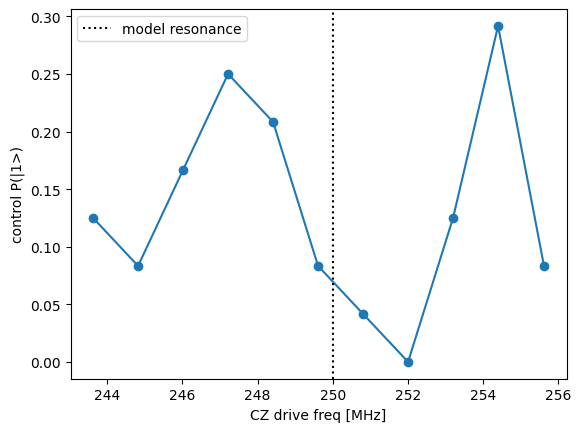

CZ/freq -> 251.215 MHz  (truth 250.0)


In [19]:
drv.sim.set_model(twoqubit_model(seed=35))
cfg = cfg2q()
czs = step(CZSweep(cfg, PAIR, 'freq', span=6 * MHz, points=11, shots=24))

d = czs.data[PAIR]
plt.plot(d['x'] / MHz, d['y'], 'o-')
plt.axvline(F_CZ_TRUE / MHz, color='k', ls=':', label='model resonance')
plt.xlabel('CZ drive freq [MHz]'); plt.ylabel('control P(|1>)'); plt.legend(); plt.show()
print(f"CZ/freq -> {cfg['two_qubit/(0, 1)/CZ/freq'] / MHz:.3f} MHz  (truth {F_CZ_TRUE / MHz:.1f})")

## CZ frequency — the conditionality R

`CZFrequency`: the four tomography sequences ({control |0⟩/|1⟩} × {Y90/X90 close}) per swept
carrier, R = the length of the conditional Bloch-vector split on the target — 1 at a conditional-π
CZ. Argmax + parabola refine; fails loud (no write) below a genuine conditional response
(max R ≤ 0.5). At co-sim shot counts through the collapse readout R hovers AROUND that acceptance
(the relaxation-SNR limit, spec 01 §4.4) — a refusal keeps the seed/dip value, which already sits
within the sweep's resolution of the model resonance.

CZFrequency (0, 1): ok=False  [191s]  proposal={}
  fit failed — config left unchanged (fail-loud, spec 13 §2)


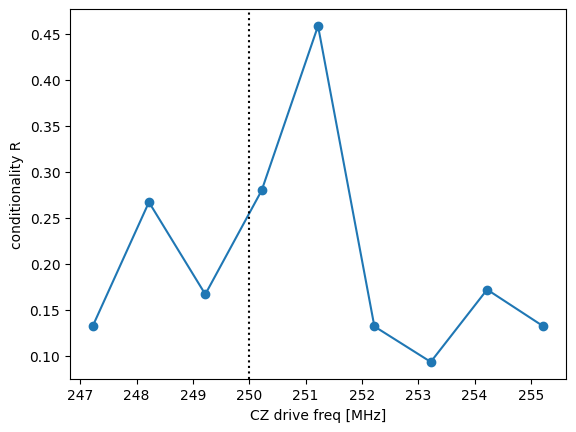

CZ/freq -> 251.215 MHz  (truth 250.0)


In [20]:
drv.sim.set_model(twoqubit_model(seed=37))
cfg = cfg2q()
czf = step(CZFrequency(cfg, PAIR, span=4 * MHz, points=9, ngates=1, shots=24))

d = czf.data[PAIR]
plt.plot(d['x'] / MHz, d['R'], 'o-')
plt.axvline(F_CZ_TRUE / MHz, color='k', ls=':')
plt.xlabel('CZ drive freq [MHz]'); plt.ylabel('conditionality R'); plt.show()
print(f"CZ/freq -> {cfg['two_qubit/(0, 1)/CZ/freq'] / MHz:.3f} MHz  (truth {F_CZ_TRUE / MHz:.1f})")

## Relative phase — the drive form's own knob

`RelativePhase` (X2 — no coupler-form analog): host-paced `write_slot('phase')` on the TARGET
core's cz slot, the four tomography reruns per point, over a full turn. The model's two
absolute-time-referenced lines sum coherently — |E| = 2A·cos(Δφ/2) — so R peaks where the round
trip completes, at the planted optimum Δφ = 0 (the tree starts 2.0 rad off), and writes the target
drive entry's `kwargs/phase`. Same SNR caveat as `CZFrequency`: below max R = 0.5 it refuses
rather than writing a noise peak — the closed-form R(Δφ) physics is pinned host-side
(`test_twoqubit_drive_form_R_extremal_at_optimal_relative_phase`) and the two-line DAC coherence
by the committed X2 capture gate.

RelativePhase (0, 1): ok=False  [145s]  proposal={}
  fit failed — config left unchanged (fail-loud, spec 13 §2)


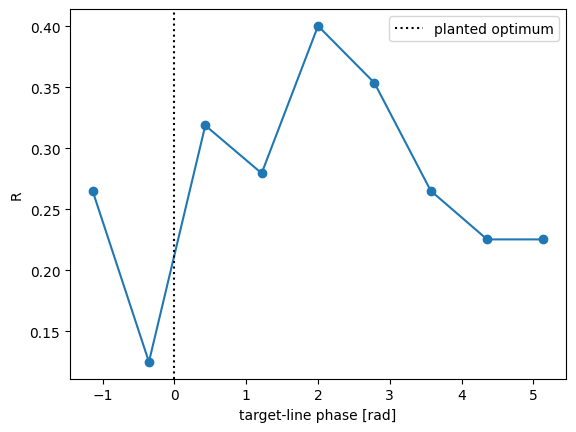

target line phase: 2.000 -> +2.000 rad  (planted optimum 0)


In [21]:
drv.sim.set_model(twoqubit_model(seed=39))
cfg = cfg2q()
rp = step(RelativePhase(cfg, PAIR, points=9, shots=16))

d = rp.data[PAIR]
plt.plot(d['x'], d['R'], 'o-')
plt.axvline(0.0, color='k', ls=':', label='planted optimum')
plt.xlabel('target-line phase [rad]'); plt.ylabel('R'); plt.legend(); plt.show()
ph_now = [p for p in cfg['two_qubit/(0, 1)/CZ/pulse']
          if not isinstance(p, str) and p.get('env') != 'virtualz'][1]['kwargs']['phase']
print(f'target line phase: 2.000 -> {ph_now:+.3f} rad  (planted optimum 0)')

## CZ amplitude — the error-amplification ladder

`CZAmplitude`: for each n in the ladder, sweep the amp of BOTH lines lockstep in a window that
narrows with n and refine on the R vertex — n CZs amplify a residual amplitude error. **Short
ladder (1, 3)**: every pulse parameter sits behind a depth-4 posted-link queue and the unpaced
higher rungs exceed the scheduled-ahead bound (spec 04 X4 — the hardware twin carries the same
note). The planted truth is the config amp itself (rabi_cz was sized to it), so the ladder should
stay near 0.35.

CZAmplitude (0, 1): ok=True  [158s]  proposal={'two_qubit/(0, 1)/CZ/pulse': [{'channel': 'Q0.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.33797954398379576, 'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.33797954398379576, 'phase': 2.0}}, {'channel': 'Q0.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/0/GE/freq', 'kwargs': {'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/1/GE/freq', 'kwargs': {'phase': 0.0}}, {'channel': 'Q2.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/2/GE/freq', 'kwargs': {'phase': 0.0}}]}


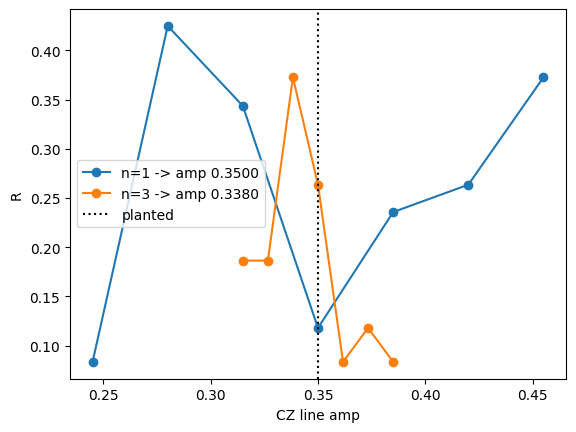

In [22]:
drv.sim.set_model(twoqubit_model(seed=41))
cfg = cfg2q()
cza = step(CZAmplitude(cfg, PAIR, n_gates=(1, 3), window=0.3, points=7, shots=12))

for p in cza.data[PAIR]['passes']:
    plt.plot(p['x'], p['R'], 'o-', label=f"n={p['n']} -> amp {p['amp']:.4f}")
plt.axvline(CZ_AMP, color='k', ls=':', label='planted')
plt.xlabel('CZ line amp'); plt.ylabel('R'); plt.legend(); plt.show()

## Local phases

`LocalPhases`: the Ramsey `Y90 · CZ · Rz(φ) · Y90` on each pair member while the other spectates in
|0⟩/|1⟩; the correction is the |0⟩-branch peak midpointed with the |1⟩-branch peak AFTER its
conditional π is removed (`_branch_correction` — the X1 parity fix; the raw midpoint carried ±π/2
with a noise-unstable sign). On the drive form the retune round-trip's deterministic frame slip
lands exactly here. Writes both channel-matched virtual-Z entries of the pair's pulse list.

LocalPhases (0, 1): ok=True  [100s]  proposal={'two_qubit/(0, 1)/CZ/pulse': [{'channel': 'Q0.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.33797954398379576, 'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.33797954398379576, 'phase': 2.0}}, {'channel': 'Q0.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/0/GE/freq', 'kwargs': {'phase': 1.9427678928860814}}, {'channel': 'Q1.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/1/GE/freq', 'kwargs': {'phase': 1.912003154084153}}, {'channel': 'Q2.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/2/GE/freq', 'kwargs': {'phase': 0.0}}]}


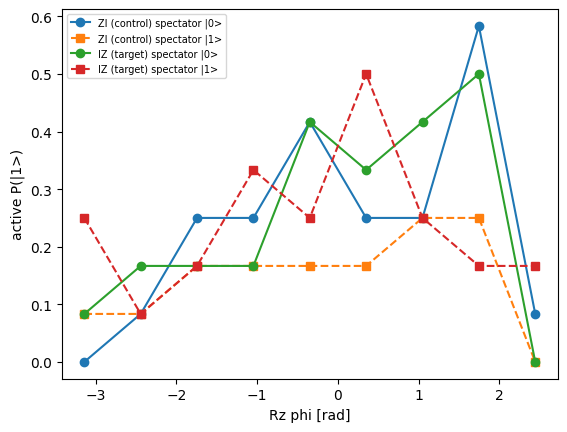

zi=+1.943  iz=+1.912 rad  -> written into the Q0/Q1 virtualz entries


In [23]:
drv.sim.set_model(twoqubit_model(seed=43))
cfg = cfg2q()
lp = step(LocalPhases(cfg, PAIR, points=9, shots=12))

d = lp.data[PAIR]
for role, dd in (('ZI (control)', d['ZI']), ('IZ (target)', d['IZ'])):
    for sp in (0, 1):
        plt.plot(d['phi'], dd[sp]['P'], 'o-' if sp == 0 else 's--',
                 label=f'{role} spectator |{sp}>')
plt.xlabel('Rz phi [rad]'); plt.ylabel('active P(|1>)'); plt.legend(fontsize=7); plt.show()
print(f"zi={d['zi']:+.3f}  iz={d['iz']:+.3f} rad  -> written into the Q0/Q1 virtualz entries")

## Spectator phase — the 3-core stage

`SpectatorPhase` (X3): the LocalPhases Ramsey on core 2 — a ring NEIGHBOUR outside the gate —
bracketing the pair's CZ fire (the ±LEAD margins absorb the unequal-gate-table grid offset, the X3
finding), qcal's two circuits as sp = 0/1 reruns, the wrap-aware plain mean (NO conditional-π
removal — the spectator is outside the gate). The model becomes `multi`: the drive-form pair PLUS
an independent `TwoLevelModel` bystander — independent, so the planted kick is 0 and the written
Q2 virtual-Z should sit near 0 (the real chip's static-ZZ kick is what the hardware twin
measures). All three readout tones now share the ADC (3 × 10000).

SpectatorPhase (0, 1) Q2: ok=True  [59s]  proposal={'two_qubit/(0, 1)/CZ/pulse': [{'channel': 'Q0.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.33797954398379576, 'phase': 0.0}}, {'channel': 'Q1.qdrv', 'env': 'square', 'time': 3e-07, 'kwargs': {'amp': 0.33797954398379576, 'phase': 2.0}}, {'channel': 'Q0.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/0/GE/freq', 'kwargs': {'phase': 1.9427678928860814}}, {'channel': 'Q1.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/1/GE/freq', 'kwargs': {'phase': 1.912003154084153}}, {'channel': 'Q2.qdrv', 'env': 'virtualz', 'time': 0.0, 'freq': 'single_qubit/2/GE/freq', 'kwargs': {'phase': 0.2561183665997637}}]}


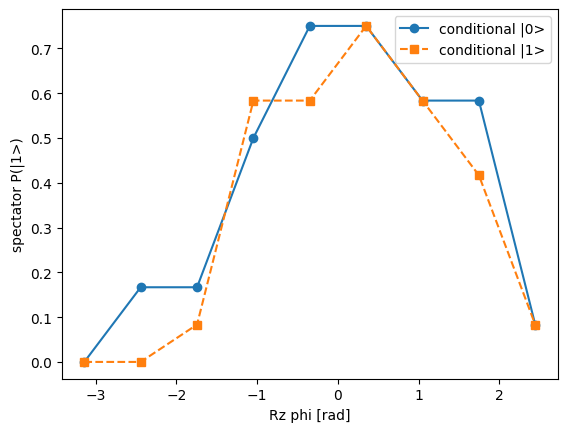

spectator correction -> +0.256 rad (independent bystander model: planted 0)


In [24]:
spect_rabi = (math.pi / 2) / x90_sigma(2, 0.5)             # its X90 (amp 0.5) = π/2
drv.sim.set_model({'kind': 'multi', 'models': [
    twoqubit_model(seed=45),
    dict(kind='twolevel', core=SPECT, rabi_rad_per_amp=spect_rabi, readout_code=RO_CODE[SPECT],
         readout_amp=10000.0, readout_phase=0.0, f_ge=F_GE[SPECT], t1=600, t2=3000,
         noise_scale=250.0, noise_seed=47, collapse=True)]})
cfg = cfg2q()
sp = step(SpectatorPhase(cfg, PAIR, spectator=SPECT, points=9, shots=12))

d = sp.data[PAIR]
for c in (0, 1):
    b = d['branches'][c]
    plt.plot(d['phi'], b['P'], 'o-' if c == 0 else 's--', label=f'conditional |{c}>')
plt.xlabel('Rz phi [rad]'); plt.ylabel('spectator P(|1>)'); plt.legend(); plt.show()
print(f"spectator correction -> {d['corr']:+.3f} rad (independent bystander model: planted 0)")

## Validation — R at an amplified gate count

The chain's own conditionality machinery (`_cz_cond_R` — the `CZFrequency`/`CZAmplitude`
measurement pinned at the calibrated knob): R at n = 1 vs n = 3 CZs. On the calibrated tree the
amplified R should hold up; at these shot counts the values are noisy handles, not gates.

In [25]:
cfg = cfg2q()
for n in (1, 3):
    R, _ = _cz_cond_R(cfg, drv, m, PAIR, 'freq', _cz_freq_word(cfg, PAIR, m), 0, 1, n, 24)
    print(f'R at n={n} CZs: {float(R[0]):.3f}')

R at n=1 CZs: 0.125


R at n=3 CZs: 0.300


# Summary — what the flow wrote

The calibrated working tree against the pristine config of record: every changed path, through the
full `from_qcal`/`save_qcal` round trip (EF and two-qubit keys land in the artefact via the X0
adapter; `ZZ11` lives only in the run's Result — the known adapter gap).

In [26]:
def flat(c, prefix='', out=None):
    out = {} if out is None else out
    for k, v in (c if isinstance(c, dict) else c.to_dict()).items():
        p = f'{prefix}/{k}' if prefix else str(k)
        if isinstance(v, dict):
            flat(v, p, out)
        else:
            out[p] = v
    return out

before, after = flat(Config.from_qcal(SRC)), flat(Config.from_qcal(WORK))
changed = [p for p in sorted(after) if after[p] != before.get(p)]
for p in changed:
    print(f'{p}: {before.get(p)} -> {after[p]}')
print(f'\n{len(changed)} calibrated paths; tree of record: {WORK}')
mark('flow complete')

qubit/0/EF/freq: 450000000.0 -> 451464843.75
qubit/0/EF/x/amp: 0.4 -> 0.11539460077075761
qubit/0/EF/x90/amp: 0.4 -> 0.06990255249459859
qubit/0/freq: 50000000.0 -> 50008682.518267855
qubit/0/x90/amp: 0.5 -> 0.16017075074768403
qubit/0/x90/vz: [0.0, 0.0] -> [-0.27109484518565335, -0.27109484518565335]
qubit/1/EF/freq: 650000000.0 -> 648535156.25
qubit/1/EF/x/amp: 0.4 -> 0.23742745174680555
qubit/1/EF/x90/amp: 0.4 -> 0.29316057555223074
qubit/1/freq: 150000000.0 -> 149981134.0993924
qubit/1/x90/amp: 0.5 -> 0.09429046564588119
qubit/1/x90/vz: [0.0, 0.0] -> [-0.04371782685083068, -0.04371782685083068]
readout/0/amp: 0.5 -> 0.49502412545235225
readout/0/demod/phase: 0.0 -> 1.5331437136281956
readout/1/amp: 0.5 -> 0.49502412545235225
readout/1/demod/phase: 0.0 -> 0.729408155604452
readout/2/amp: 0.5 -> 0.49502412545235225
readout/2/demod/phase: 0.0 -> 2.3626716411065054
two_qubit/(0, 1)/CZ/freq: 242000000.0 -> 251215177.09187683
two_qubit/(0, 1)/CZ/pulse: [{'channel': 'Q0.qdrv', 'env': 'squ

## Tear down the co-sim

In [27]:
drv.sim.set_model({'kind': 'zero'})
server.stop(drv)
print('cosim stopped')

cosim stopped
